# Coursework Set Week 5

**Common remarks**:

* Deadline: Sunday at 23:59h for the scheduled week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Lotte van Mispelaar
* Username: lkmispelaar
* Student number: S6394973
* Group (AS1, etc.): AS2

-----

In [1]:
totalpoints = currentpoints = 0

### Plotting a galaxy rotation curve from data in a text file (4 pt) <font color='red'><b>COURSEWORK</b></font>

This qustion you will use data from an observation of NGC 6946. The stellar mass of NGC 6946 is $M_* = 2\times10^{10} M_{\odot}$, where $M_{\odot}$ represent *solar mass (the mass of the Sun)*. 

* Copy/download the file [rotcur.dat](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/rotcur.dat). This text file contains the output of a program that calculates rotation curves. Examine its contents on the Linux command line with a pager like ``more`` or in an editor so that you know what the columns represent.
* Write a program, that reads the columns `radius` and `rotation velocity`. Radii are in **kpc** and velocities in **km/s**.
* Create a line plot where the $x$-axis represents the radius and the $y$-axis represents the rotation velocity.
* Calculate the Keplerian rotation curve using $v=\sqrt{\frac{GM}{r}}$
* Create and save a text file called ``keplerian_curve.txt`` using ``np.savetxt()``.
* Using ``np.loadtxt()`` to load your Keplerian curve and plot it together with the observation data.
* Force the lower limit of the $y$-axis range to 0 and the upper limit to maximal values of the Keplerian curve.
* Annotate the plot with relevant information.
* Make comment about your observation.

**Answers**:

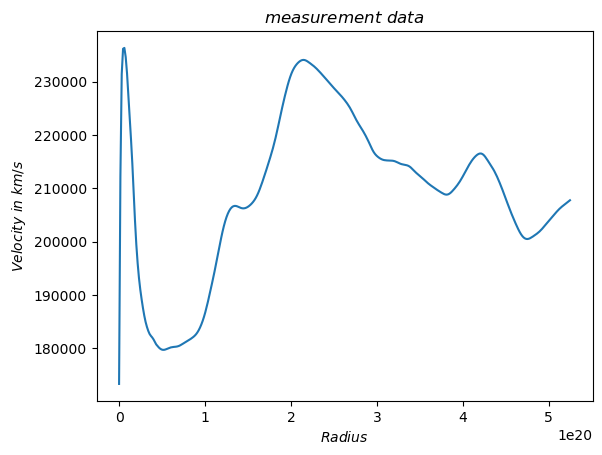

In [36]:
# viewing the file with command line is shown below

import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import G

M_sol = 1.98892 * 10**30
M = 2*(10**10) * M_sol # kilograms
dat = open('rotcur.dat', 'r')
data = np.loadtxt(dat)

# filtering data with slicing
data = data.flatten()
R = data[::2]* 3.0857E+19 # conversion to meters
V = data[1::2]*1000 # conversion to m/s

# plotting
plt.plot(R, V, label = '$measurement\ data$')
R2 = list(R)
R2.pop(0)
R2 = np.array(R2)
v = np.sqrt(G*M/R2)
plt.title('$measurement\ data$')
plt.xlabel('$Radius$')
plt.ylabel('$Velocity\ in\ km/s$')
plt.show()

np.savetxt('keplerian_curve.txt', np.hstack((np.vstack(v), np.vstack(R2))))

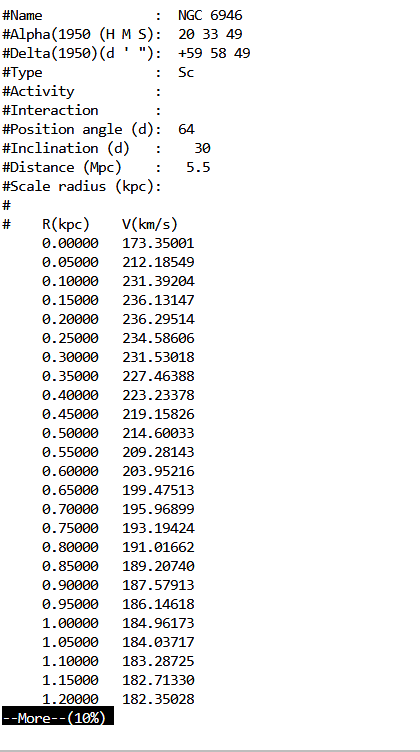

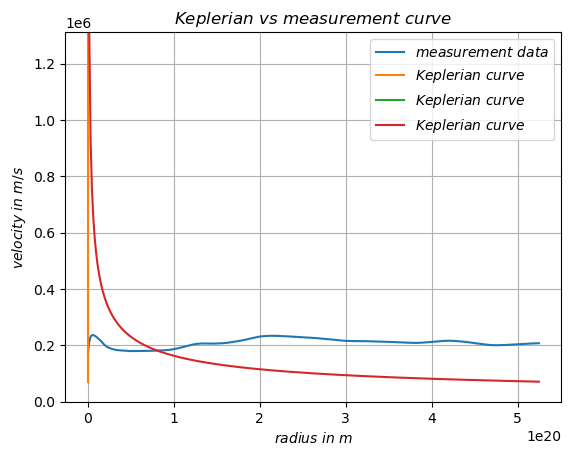

In [37]:
data = np.loadtxt('keplerian_curve.txt')
plt.plot(R, V, label = '$measurement\ data$')
plt.plot(data, label = '$Keplerian\ curve$')
plt.plot(R2, v, label = '$Keplerian\ curve$')
plt.ylim(0, np.max(v))
plt.title('$Keplerian\ vs\ measurement\ curve$')
plt.xlabel('$radius\ in\ m$')
plt.ylabel('$velocity\ in\ m/s$')
plt.grid()
plt.legend()
plt.show()

In [4]:
'''The keplerian rotation curve describes the fall off of the rotational speed as a function of velocity.
It is visible in the graph that the keplerian curve accurately shows the extreme fall off of the velocity at close radii, however it seems to fail to show the fall off at higher radii.'''

'The keplerian rotation curve describes the fall off of the rotational speed as a function of velocity.\nIt is visible in the graph that the keplerian curve accurately shows the extreme fall off of the velocity at close radii, however it seems to fail to show the fall off at higher radii.'

<div class='alert alert-warning'>
    <b>Feedback</b> <br>

You are not using the data from `keplerian_curve.txt` to plot your graph. <b>[0.5pt deducted from total grade.]</b>
</div>

In [5]:
# Leave unaltered
totalpoints += 4
currentpoints += 3.5

### Exploring image noise (3 pt)  <font color='red'><b>COURSEWORK</b></font>
   
* Create a two dimensional NumPy array with 200 rows and 300 columns filled with pixel values drawn from the normal distribution ``numpy.random.normal()`` with a mean of 0 and standard deviation 1.0.
* Use ``plt.imshow()`` to plot the image. The figure must be 8 inches wide and 4 inches high.
* Use color map ``jet`` for your image.
* Take a small two dimensional slice (e.g. 30x30 pixels) somewhere in the image and calculate the mean and standard deviation of the pixel values in your slice.
* Are this mean and standard deviation what you expected?
* Plot a histogram of all image values in 50 bins (you will need to ravel/flatten the data first). To not overlap with the previous plot, you probably need to create a new plot ``plt.figure()``. What distribution should you recognise?

**Answer**:

for big figure mean = 0.0053343438772057855, stdev = 1.0018641827891428
for tiny figure mean = 0.060831066501482255, stdev = 0.9709725742603451


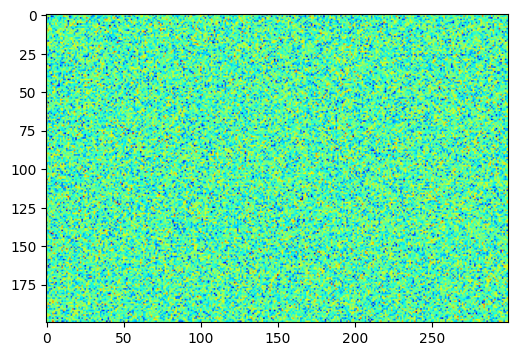

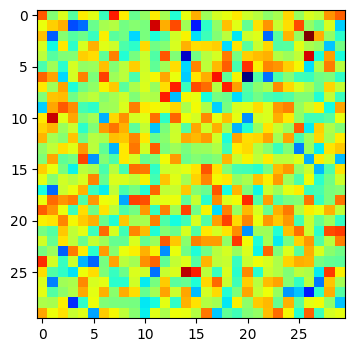

In [6]:
import numpy as np
import matplotlib.pyplot as plt

x = np.random.normal(0, 1.0, 60000).reshape(200, 300)

# first figure
plt.figure(figsize = (8, 4))
plt.imshow(x, 'jet')

# second figure and values
y = x[0:30, :30]
print(f'for big figure mean = {np.mean(x)}, stdev = {np.std(x)}')
print(f'for tiny figure mean = {np.mean(y)}, stdev = {np.std(y)}')

plt.figure(figsize = (8, 4))
plt.imshow(x[0:30, :30], 'jet')
plt.show()

The mean and standard deviation are what I expected. The values are near the actual values I set for the whole figure, but with a slight deviation due to the limited data in that slice. The mean however does deviate more than I would have expected, but that is because of the limited data in this slice

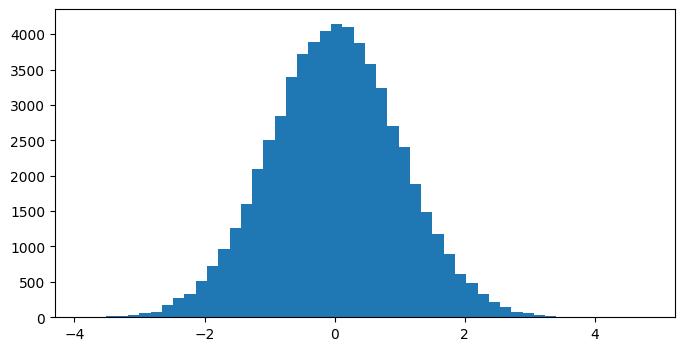

In [7]:
x = x.flatten()
plt.figure(figsize = (8, 4))
plt.hist(x, bins = 50)
plt.show()

In [8]:
# This is a histogram of the gaussian distribution

In [9]:
# Leave unaltered
totalpoints += 3
currentpoints += 3

### Extending the Ellipse class (6 pt) <font color='red'><b>COURSEWORK</b></font>

* Copy the code for class ``AstroEllipse`` in the section.
* Extend the class with a method that calculates and returns the area of the ellipse.
* Extend the class with a method that calculates and returns the perimeter of the ellipse (keywords: Ramanujan’s formula for perimeter of ellipse).
* Give an example of the creation of an ellipse with semi major axis equal to 3 and semi minor axis equal to 2 and call the methods for area and perimeter to show what the area and perimeter is for this ellipse.
* Add a method ``__str__()`` which returns a string with the values of the ellipse parameters (center, axes and angle) and demonstrate the method with ``print()``.
* Create a class ``MyCircle`` which inherits from class ``AstroEllipse``. The arguments for its ``__init__()`` function is a center position and a radius.
* Create a plot with three circles with random origins and radii. The circles must have different colors and the  transparency (``alpha=``) must be set to 0.5. Use the ``Axes`` object (Section 5.7) to add the circles to the plot.

**Answers**:

For semi major = 3 and semi minor = 2: Perimeter = 15.865437575563961, area = 18.84955592153876, centre = (1, 4), angle = 30, axes: semi major = 3, semi minor = 2


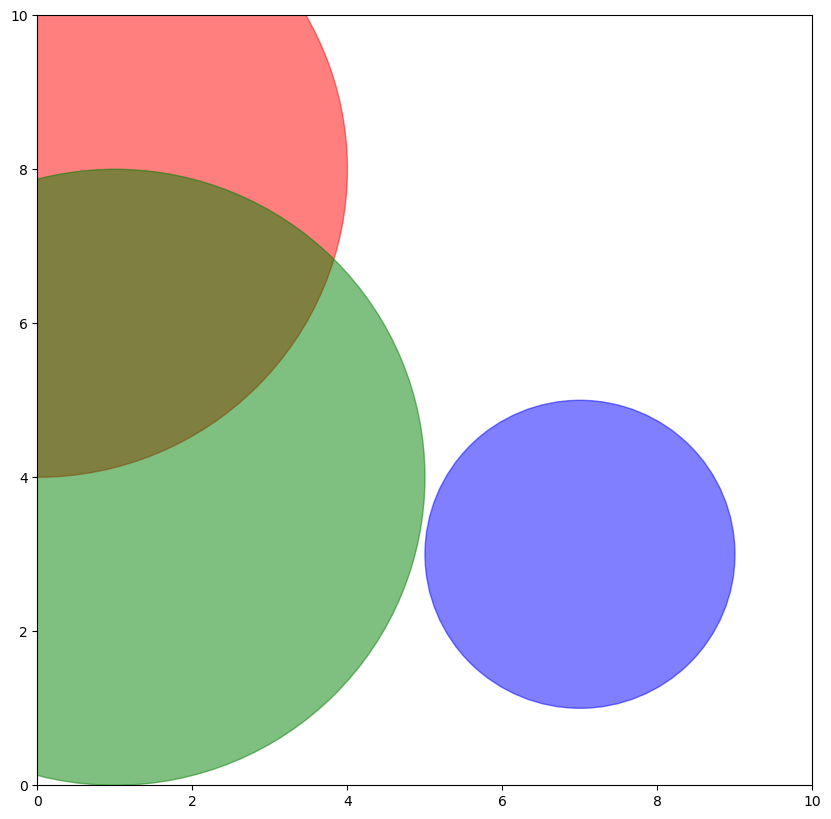

In [16]:
from matplotlib.patches import Ellipse, Circle
from numpy import pi
from matplotlib.pyplot import figure, show, imshow, plot
from matplotlib import pyplot as plt
import random

class AstroEllipse(Ellipse):
    def __init__(self, xc, yc, semi_major, semi_minor, position_angle, color="blue", **args):
        # We use the (sort of) astronomical angle where 'angle' defines)
        # the position angle of the major axis of a ring projected onto the sky
        # (i.e. an ellipse). This is an angle taken in anti-clockwise direction between
        # the north direction on the sky and the major axis of the receding half of the
        # galaxy (Rots 1975, astron, astrophys 45, 43).
        # Here we assume (!) north is in the positive Y direction.
        # If not, you need to correct the angle for the rotation of the image.
        # Parameter 'position_angle' enters in degrees
        assert(semi_major >= semi_minor)  # Prerequisite to make angle unambiguous
        self.XY = (xc, yc)                  # MPL requires center as a tuple
        self.angle_mpl = position_angle     # Angle for MatPlotLib's ellipse patch
        height = 2.0*semi_major        # height: is along vertical axis for an unrotated ellipse
        width  = 2.0*semi_minor        # width:  is along horizontal axis for an unrotated ellipse
        self.semi_major = semi_major
        self.semi_minor = semi_minor
        super().__init__(self.XY, width, height, angle=self.angle_mpl, color=color, **args)
        
    def perimeter(self): # using Ramanujan's first formula for the perimeter of an ellipse
        return pi * (3 * (self.semi_major + self.semi_minor) - ((3 * self.semi_major + self.semi_minor) * (self.semi_major + 3 * self.semi_minor))**0.5)
    def area(self):
        return pi * self.semi_major * self.semi_minor
    def __str__(self):
        return f'centre = {self.XY}, angle = {self.angle_mpl}, axes: semi major = {self.semi_major}, semi minor = {self.semi_minor}'

sem_major = 3
sem_minor = 2
position_angle = 30
astro = AstroEllipse(1, 4, sem_major, sem_minor, position_angle)
print(f'For semi major = {sem_major} and semi minor = {sem_minor}: Perimeter = {astro.perimeter()}, area = {astro.area()},', astro.__str__())

class MyCircle(AstroEllipse):
    def __init__(self, x_c, y_c, r, color, alpha = 0.5):
        self.x_c = x_c
        self.y_c = y_c
        self.r = r
        super().__init__(self.x_c, self.y_c, self.r, self.r, 0, color, alpha=alpha)
    def circle(self):
        return (self.x_c, self.y_c,), self.r, self.alpha

fig, ax = plt.subplots(figsize = (10, 10))

ax.add_patch(MyCircle(random.randint(0, 10), random.randint(0, 10), random.randint(1, 5), "red"))
ax.add_patch(MyCircle(random.randint(0, 10), random.randint(0, 10), random.randint(1, 5), "green"))
ax.add_patch(MyCircle(random.randint(0, 10), random.randint(0, 10), random.randint(1, 5), "blue"))

plt.xlim(0, 10)
plt.ylim(0, 10)
plt.show()

<div class='alert alert-warning'>
    <b>Feedback</b> <br>

Your circle's position and radius are not random. <b>[1pt deducted from total grade.]</b>

You didn't define the transparency of the circles. Yes, you do have a standard `alpha = 0.5` in your `super().__init__()`, but try to see if you can pass the alpha argument in your `MyCircle` class. <b>[0.5pt deducted from total grade.]</b>

Also the method Circle in your MyCircle class seems obsolete. 
</div>

In [11]:
# Leave unaltered
totalpoints += 6
currentpoints += 4.5

### Plotting Bessel's function (3 pt) <font color='red'><b>COURSEWORK</b></font>
   
The differential equation of Bessel is:

$$x^2\ \frac{d^2y}{dx^2}+x\ \frac{dy}{dx}+(x^2-a^2)y=0$$

Solutions of this equation are called Bessel functions of the first kind of real order ``a``.
Bessel functions are especially important for problems of wave propagation and static 
potentials and in solutions to the radial Schrodinger equation in quantum mechanics. 

Module ``special`` in package SciPy provides Bessel functions with the import statement:

```python
from scipy.special import jv
```

Write code that plots a solution of Bessel's differential equation for ``a=1,2,3`` and ``a=4`` on the interval ``x=[0,10]``in a mosaic of 2x2 plots. A Bessel function has arguments: ``jv(a, x)`` 

<font color='red'>Note: Object Oriented Plotting is required, or 1.0pt will be deducted.</font>

* Annotate your plot with a title and labels for the $x$- and $y$ axis. 
* Add a legend with labels for all curves.
* Include code that saves your figure to a file with base name ``bessel`` as a transparent PNG file.
* Attach the figure (PNG file) in the notebook.

**Code and figure**:

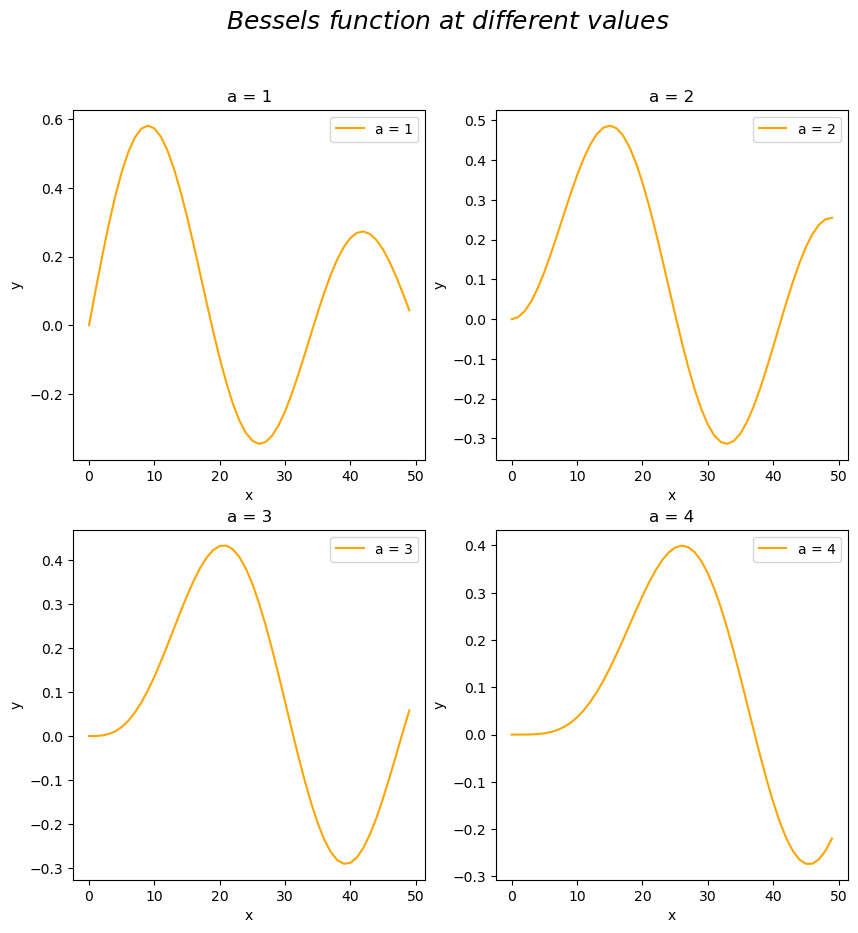

In [1]:
from scipy.special import jv
import numpy as np
from matplotlib import pyplot as plt

x = np.linspace(0, 10, 50)

fig, ax = plt.subplots(2, 2, figsize = (10, 10))

class bessel:
    def __init__ (self, a):
        self.a = a
    def bessely(self, x):   
        result = jv(a, x)
        return result

a = 0

for i in range(0, 2):
     for j in range(0, 2):
        a += 1 
        ax[i, j].plot(bessel(a).bessely(x), label = f'a = {a}', color = 'orange')
        ax[i, j].set_title(f'a = {a}')
        ax[i, j].set_xlabel('x')
        ax[i, j].set_ylabel('y')
        ax[i, j].legend()
fig.suptitle('$Bessels\ function\ at\ different\ values$', fontsize = 18)

plt.savefig('bessel.png', transparent=True)

plt.show()

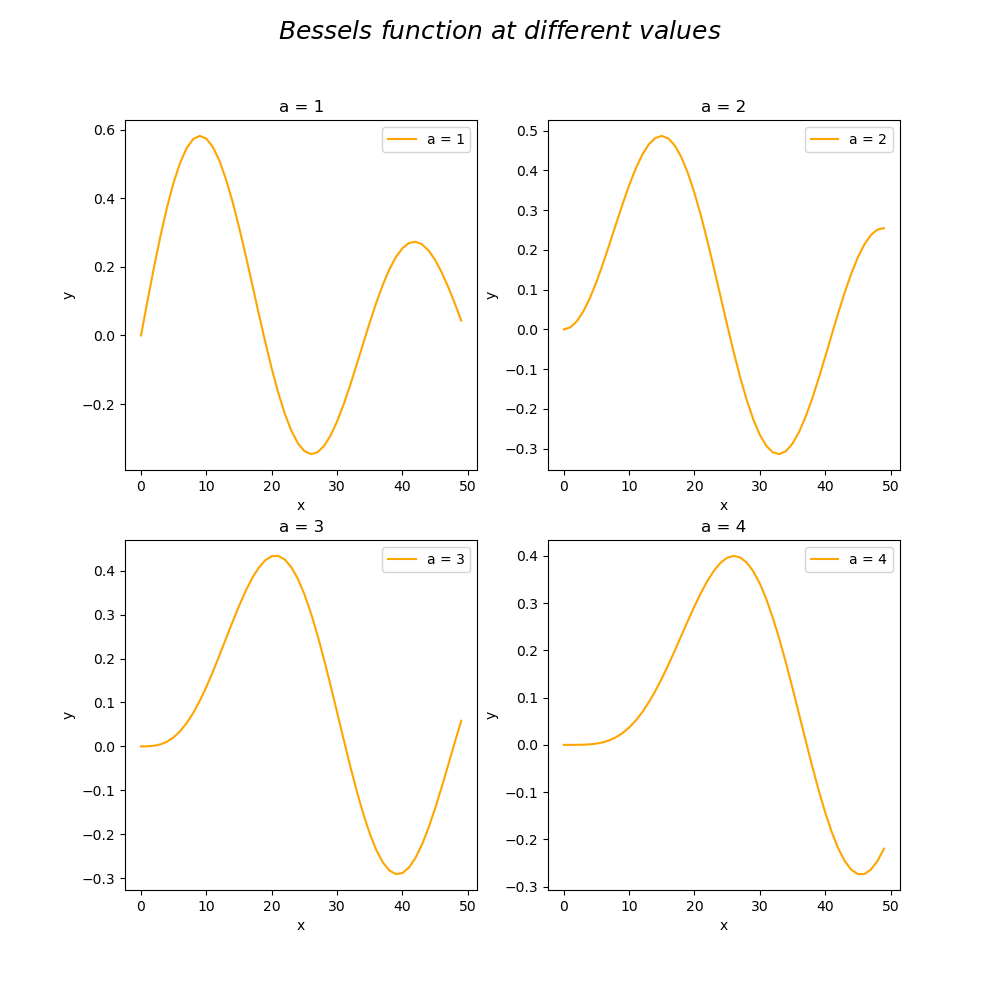

<div class='alert alert-warning'>
    <b>Feedback</b> <br>

You used functions that make the plotting not 100% Object Oriented Plotting. Try to avoid to use of `plt.`, the only exception is `plt.show()`. <b>[1pt deducted from total grade.]</b>
</div>

In [13]:
# Leave unaltered
totalpoints += 3
currentpoints += 2

### Matplotlib, the right way (2 pt)  <font color='red'><b>HOMEWORK</b></font>

The following table contains the measurements of distances and velocities, including their uncertainties, for a small sample of galaxies. The table is given in the form of a Python list.

From your previous coursework, you have done chi-squared fitting to fit the following data without uncertainties. If considering the uncertainties during the fitting process, the slope of a best fit line through the data gives a value for the Hubble constant.

$$H_0 = 67.8 (km/s)/Mpc$$

```
    d(Mpc)    v(km/s)    error in d    error in v
    ==============================================
    18.49      2094.75    0.3           100
    35.48      2320.87    2.2           120
    ........
```
```python
    data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]
```

<font color='red'>In this question, you have to use the OO interface of Matplotlib to create your plot, or 1.0pt will be deducted.</font>

* Use slicing syntax to unpack ``data`` into separate variables for distance and velocity, as well as their corresponding errors.
* Create a plot for this data. Add error bars with method `errorbar() <matplotlib.axes.Axes.errorbar>`
* Plot also a line which represents the Hubble relation between distance and velocity  as a line through the origin, with a slope equal to $H_0$
* Add the value of $H_0$ to the legend using LaTex math mode
  
**Script and plot**:

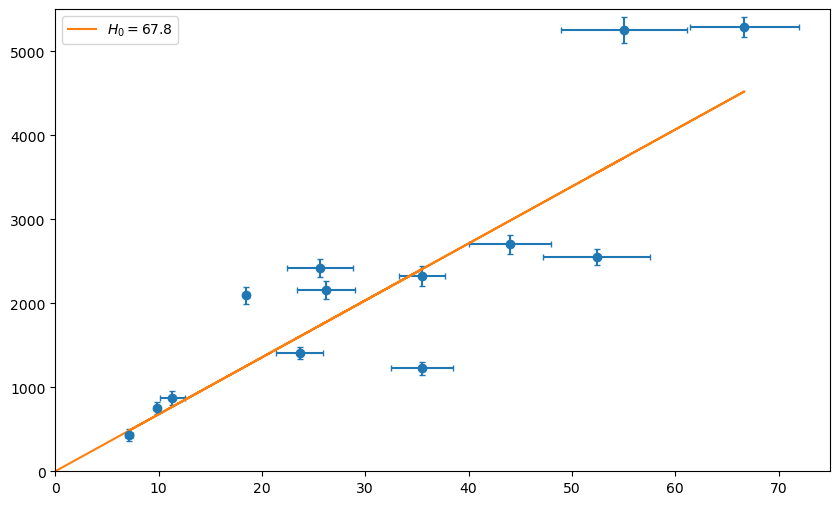

In [3]:
    data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
]

dist = data[0::4]
vel = data[1::4]
err_dist = data[2::4]
err_vel = data[3::4]

import matplotlib.pyplot as plt
import matplotlib
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(dist, vel, xerr=err_dist, yerr=err_vel, fmt='o', capsize=2)
dist.insert(0, 0)
v = 67.8 *np.array(dist)
ax.plot(dist, v, label = '$H_0 = 67.8$')
ax.set_xlim(0, 75)
ax.set_ylim(0, 5500)
ax.legend()
plt.show()

<div class='alert alert-warning'>
    <b>Feedback</b> <br>

You used functions that make the plotting not 100% Object Oriented Plotting. Try to avoid to use of `plt.`, the only exception is `plt.show()`. <b>[1pt deducted from total grade.]</b>
</div>

In [15]:
# Leave unaltered
totalpoints += 2
currentpoints += 1

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [16]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")

Total number of points: 18. Student score: 14.0.  Task Grade = 7.8
